Procesamiento de datos y Transformacion a conveniencia

In [28]:
# Exploracion data\estimaciones-y-proyecciones-de-población-1992-2070_base-2024_base-de-datos.xlsx

import pandas as pd
import matplotlib.pyplot as plt

In [34]:
df = pd.read_excel("estimaciones-y-proyecciones-de-población-1992-2070_base-2024_base-de-datos.xlsx")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31916 entries, 0 to 31915
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   NIVEL      31916 non-null  object
 1   SEXO       31916 non-null  object
 2   FECHA      31916 non-null  object
 3   EDAD       31916 non-null  int64 
 4   POBLACION  31916 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 1.2+ MB


In [35]:
df["FECHA"] = pd.to_datetime(df["FECHA"], dayfirst=True) # Formato distinto al americano (creo)
df = df[(df["FECHA"].dt.month == 1) & (df["FECHA"].dt.day == 1)]

df["AÑO"] = df["FECHA"].dt.year
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15958 entries, 0 to 15957
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   NIVEL      15958 non-null  object        
 1   SEXO       15958 non-null  object        
 2   FECHA      15958 non-null  datetime64[ns]
 3   EDAD       15958 non-null  int64         
 4   POBLACION  15958 non-null  int64         
 5   AÑO        15958 non-null  int32         
dtypes: datetime64[ns](1), int32(1), int64(2), object(2)
memory usage: 810.4+ KB


In [44]:
# Agrupo por año y edad, sin considerar sexo
resumen = df.groupby(["AÑO", "EDAD"])["POBLACION"].sum().reset_index()
resumen.head(10)



,AÑO,EDAD,POBLACION
0,1992,0,297076
1,1992,1,301745
2,1992,2,301443
3,1992,3,289459
4,1992,4,276507
5,1992,5,264099
6,1992,6,258368
7,1992,7,255080
8,1992,8,258094
9,1992,9,264998


In [ ]:
# DataFrame diltrado para visualizacion

df_fil_vis = resumen[(resumen["EDAD"] < 18) | (resumen["EDAD"] > 60)].copy()

df_fil_vis["Grupo_Edad"] = df_fil_vis["EDAD"].apply(lambda x: "0-17" if x < 18 else "60+")

df_fil_vis = df_fil_vis.groupby(["AÑO", "Grupo_Edad"])["POBLACION"].sum().reset_index()
#df_fil_vis.head()


Index(['AÑO', 'Grupo_Edad', 'POBLACION'], dtype='object')

In [ ]:
total_values = resumen.groupby("AÑO")["POBLACION"].sum().reset_index(name="TOTAL")

df_fil_vis = df_fil_vis.merge(total_values, on="AÑO")
df_fil_vis["PORCENTAJE"] = df_fil_vis["POBLACION"] / df_fil_vis["TOTAL"] * 100
#df_fil_vis.head()

,AÑO,Grupo_Edad,POBLACION,TOTAL_x,PORCENTAJE,TOTAL_y,TOTAL
0,1992,0-17,4756539,13658885,34.823772,13658885,13658885
1,1992,60+,1230417,13658885,9.008180,13658885,13658885
2,1993,0-17,4789378,13882702,34.498889,13882702,13882702
3,1993,60+,1270072,13882702,9.148594,13882702,13882702
4,1994,0-17,4826832,14099547,34.233951,14099547,14099547


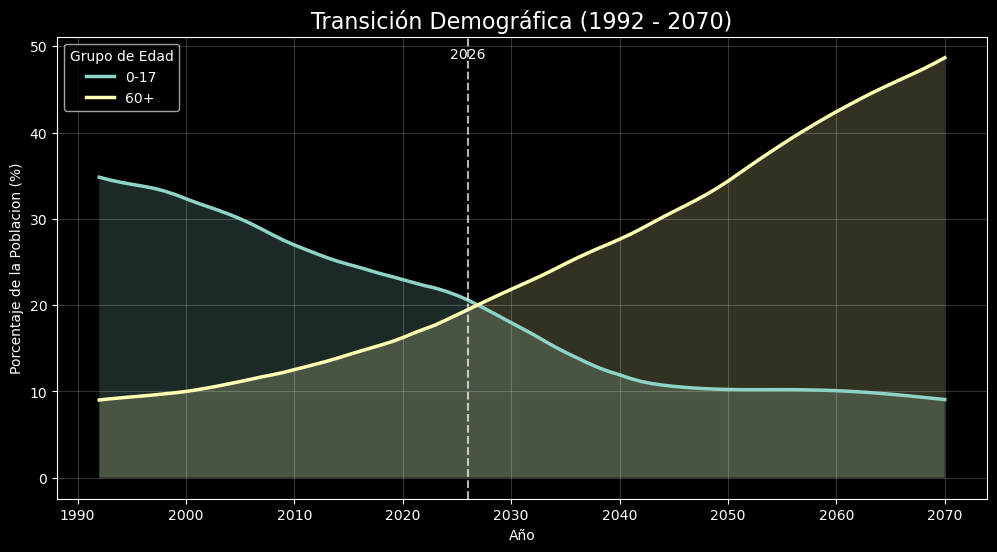

In [57]:
# Visualizacion generada, con el estilo 


plt.style.use("dark_background")
plt.figure(figsize=(12,6))

for grupo, color in zip(["0-17", "60+"], ["cyan", "orange"]):
    subset = df_fil_vis[df_fil_vis["Grupo_Edad"] == grupo]
    
    plt.plot(subset["AÑO"], subset["PORCENTAJE"], label=grupo, linewidth=2.5)
    
    plt.fill_between(subset["AÑO"], subset["PORCENTAJE"], alpha=0.2)

# Esto representa la linea vertical en 2026, nuestro año actual
plt.axvline(x=2026, linestyle="--", alpha=0.7)
plt.text(2026, plt.ylim()[1]*0.95, "2026", ha="center")

plt.title("Transición Demográfica (1992 - 2070)", fontsize=16)
plt.xlabel("Año")
plt.ylabel("Porcentaje de la Poblacion (%)")

plt.legend(title="Grupo de Edad")
plt.grid(alpha=0.2)

plt.show()